In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_anthropic import ChatAnthropic
from typing import TypedDict, Literal
from dotenv import load_dotenv
from pydantic import BaseModel, Field

In [2]:
load_dotenv()

True

In [3]:
model = ChatAnthropic(model="claude-haiku-4-5-20251001")

In [4]:
class SentimentSchema(BaseModel):

    sentiment: Literal["positive", "negative"] = Field(description='Sentiment of the review')

In [6]:
structured_model = model.with_structured_output(SentimentSchema)

In [11]:
prompt = 'What is the sentiment of the following review - The software too bad'
structured_model.invoke(prompt)

SentimentSchema(sentiment='negative')

In [12]:
structured_model.invoke(prompt).sentiment

'negative'

In [13]:
prompt = 'What is the sentiment of the following review - The software too good'
structured_model.invoke(prompt).sentiment

'positive'

In [16]:
class ReviewState(TypedDict):

    review: str
    sentiment: Literal["positive", "negative"]
    diagnosis: dict
    response: str

In [17]:
def find_sentiment(state: ReviewState):

    prompt = f'For the following review find out the sentiment \n {state["review"]}'
    sentiment = structured_model.invoke(prompt).sentiment

    return {'sentiment': sentiment}

In [18]:
graph = StateGraph(ReviewState)

graph.add_node('find_sentiment', find_sentiment)

graph.add_edge(START, 'find_sentiment')
graph.add_edge('find_sentiment', END)

workflow = graph.compile()

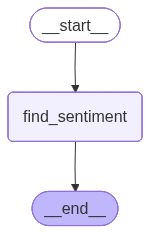

In [19]:
workflow

In [20]:
initial_state = {'review': 'The product was really good'}

workflow.invoke(initial_state)

{'review': 'The product was really good', 'sentiment': 'positive'}

In [21]:
initial_state = {'review': 'The product was really bad'}

workflow.invoke(initial_state)

{'review': 'The product was really bad', 'sentiment': 'negative'}

In [ ]:
def check_sentiment(state: ReviewState) -> Literal["positive_response", "run_diagnosis"]:

    if state['sentiment'] == 'positive':
        return 'positive_response'
    else:
        return 'run_diagnosis'
    
def positive_response(state: ReviewState):

    prompt = f"""Write a warm thank-you message in response to this review:
            \n\n\"{state['review']}\"\n
            Also, kindly ask the user to leave feedback on our website."""
    
    response = model.invoke(prompt).content

    return {'response': response}

def run_diagnosis(state: ReviewState):

    prompt = f"""Diagnose this negative review:\n\n{state['review']}\n"
            "Return issue_type, tone, and urgency.
            """
    response = structured_model2.invoke(prompt)

    return {'diagnosis': response.model_dump()}

def negative_response(state: ReviewState):

    diagnosis = state['diagnosis']

    prompt = f"""You are a support assistant.
            The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
            Write an empathetic, helpful resolution message.
            """
    response = model.invoke(prompt).content

    return {'response': response}

In [ ]:
graph = StateGraph(ReviewState)

graph.add_node('find_sentiment', find_sentiment)
graph.add_node('positive_response', positive_response)
graph.add_node('run_diagnosis', run_diagnosis)
graph.add_node('negative_response', negative_response)

graph.add_edge(START, 'find_sentiment')
graph.add_edge('find_sentiment', END)

workflow = graph.compile()